<a href="https://colab.research.google.com/github/Julfikar-Asif/Pattern-Recognition-Lab-/blob/main/222004812_JulfikarRahamanAsif.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/FALL 25 ( 11th Semester)/Pattern CSE 436 Lab /diabetes_prediction_dataset.csv"

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
df= pd.read_csv(path)
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


(100000, 9)

In [ ]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [ ]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [ ]:

from sklearn import preprocessing
level_encoder= preprocessing.LabelEncoder()
df['gender']= level_encoder.fit_transform(df['gender'])
df['smoking_history']= level_encoder.fit_transform(df['smoking_history'])
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


In [ ]:
target_column = 'diabetes'
X = df.drop(columns=[target_column])
y = df[target_column]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random forest Accuracy: {accuracy:.4f}")

Random forest Accuracy: 0.9706


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27453
           1       0.96      0.68      0.80      2547

    accuracy                           0.97     30000
   macro avg       0.96      0.84      0.89     30000
weighted avg       0.97      0.97      0.97     30000



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.9473666666666667
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     27453
           1       1.00      0.38      0.55      2547

    accuracy                           0.95     30000
   macro avg       0.97      0.69      0.76     30000
weighted avg       0.95      0.95      0.94     30000



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))


Gradient Boosting Accuracy: 0.9718666666666667
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27453
           1       0.99      0.68      0.80      2547

    accuracy                           0.97     30000
   macro avg       0.98      0.84      0.89     30000
weighted avg       0.97      0.97      0.97     30000



In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))


AdaBoost Accuracy: 0.9715333333333334
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27453
           1       1.00      0.67      0.80      2547

    accuracy                           0.97     30000
   macro avg       0.98      0.83      0.89     30000
weighted avg       0.97      0.97      0.97     30000



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = log_reg.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")

print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.9589
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     27453
           1       0.86      0.61      0.72      2547

    accuracy                           0.96     30000
   macro avg       0.91      0.80      0.85     30000
weighted avg       0.96      0.96      0.96     30000



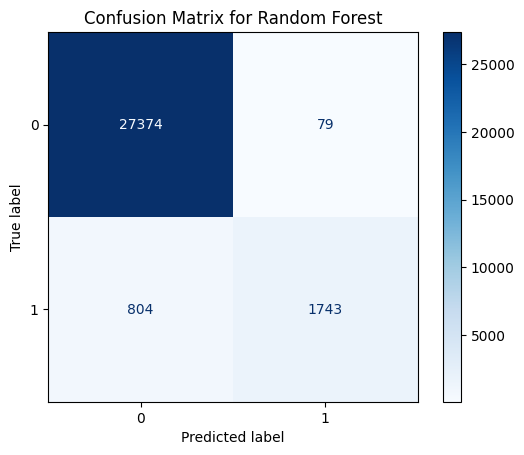

Confusion Matrix for Random Forest displayed.


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a ConfusionMatrixDisplay object and plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Random Forest')
plt.show()
print("Confusion Matrix for Random Forest displayed.")

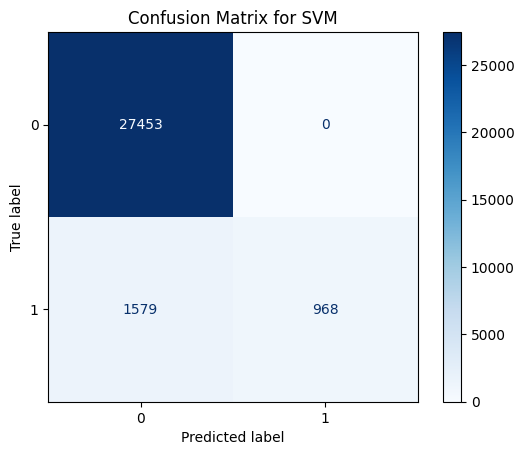

Confusion Matrix for SVM displayed.


In [ ]:
import matplotlib.pyplot as plt

# Compute the confusion matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Create a ConfusionMatrixDisplay object and plot it
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm.classes_)
disp_svm.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for SVM')
plt.show()
print("Confusion Matrix for SVM displayed.")

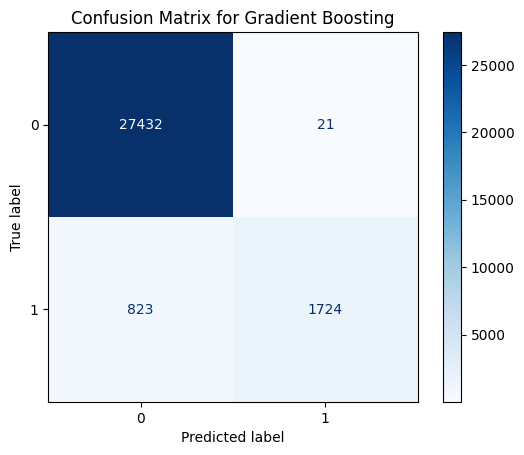

Confusion Matrix for Gradient Boosting displayed.


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute the confusion matrix for Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)

# Create a ConfusionMatrixDisplay object and plot it
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=gb.classes_)
disp_gb.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Gradient Boosting')
plt.show()
print("Confusion Matrix for Gradient Boosting displayed.")

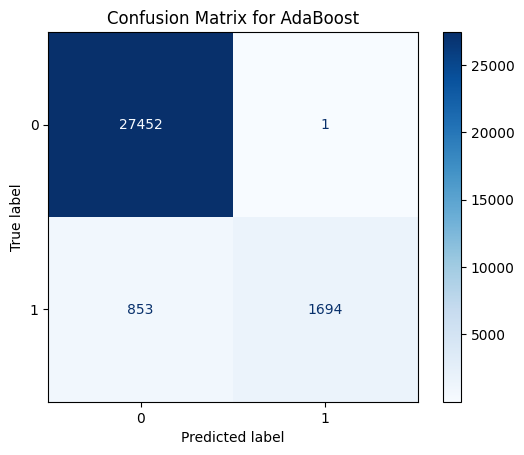

Confusion Matrix for AdaBoost displayed.


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute the confusion matrix for AdaBoost
cm_ada = confusion_matrix(y_test, y_pred_ada)

# Create a ConfusionMatrixDisplay object and plot it
disp_ada = ConfusionMatrixDisplay(confusion_matrix=cm_ada, display_labels=ada.classes_)
disp_ada.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for AdaBoost')
plt.show()
print("Confusion Matrix for AdaBoost displayed.")

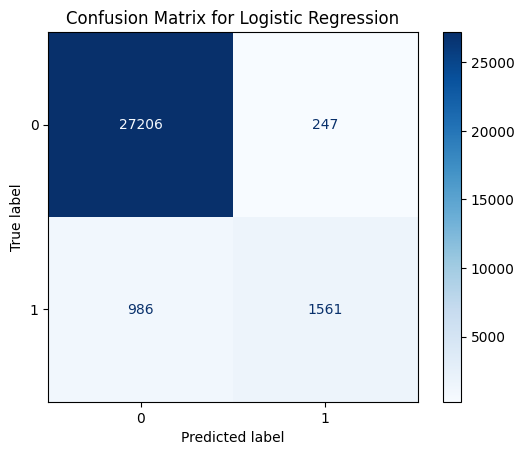

Confusion Matrix for Logistic Regression displayed.


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute the confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Create a ConfusionMatrixDisplay object and plot it
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=log_reg.classes_)
disp_lr.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression')
plt.show()
print("Confusion Matrix for Logistic Regression displayed.")

In [ ]:
model_accuracies = {
    'Random Forest': accuracy_score(y_test, y_pred),
    'SVM': accuracy_score(y_test, y_pred_svm),
    'Gradient Boosting': accuracy_score(y_test, y_pred_gb),
    'AdaBoost': accuracy_score(y_test, y_pred_ada),
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'XGBoost': accuracy_xgb,
    'CatBoost': accuracy_cat
}

print("Model Accuracies:", model_accuracies)

Model Accuracies: {'Random Forest': 0.9705666666666667, 'SVM': 0.9473666666666667, 'Gradient Boosting': 0.9718666666666667, 'AdaBoost': 0.9715333333333334, 'Logistic Regression': 0.9589, 'XGBoost': 0.9706666666666667, 'CatBoost': 0.9712}


In [ ]:
comparison_df = pd.DataFrame(list(model_accuracies.items()), columns=['Model', 'Accuracy'])
print("\nModel Comparison Table:")
print(comparison_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True))


Model Comparison Table:
                 Model  Accuracy
0    Gradient Boosting  0.971867
1             AdaBoost  0.971533
2             CatBoost  0.971200
3              XGBoost  0.970667
4        Random Forest  0.970567
5  Logistic Regression  0.958900
6                  SVM  0.947367


In [ ]:
from sklearn.metrics import classification_report

models = {
    'Random Forest': (model, X_test, y_test, y_pred),
    'SVM': (svm, X_test, y_test, y_pred_svm),
    'Gradient Boosting': (gb, X_test, y_test, y_pred_gb),
    'AdaBoost': (ada, X_test, y_test, y_pred_ada),
    'Logistic Regression': (log_reg, X_test_scaled, y_test, y_pred_lr),
    'XGBoost': (xgb_model, X_test, y_test, y_pred_xgb),
    'CatBoost': (cat_model, X_test, y_test, y_pred_cat)
}

results = []

for name, (mdl, X_t, y_t, y_p) in models.items():
    report = classification_report(y_t, y_p, output_dict=True)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_t, y_p),
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-score': report['weighted avg']['f1-score']
    })

comparison_df = pd.DataFrame(results)
print("\nFull Model Comparison Table:")
print(comparison_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True))


Full Model Comparison Table:
                 Model  Accuracy  Precision    Recall  F1-score
0    Gradient Boosting  0.971867   0.972324  0.971867  0.969441
1             AdaBoost  0.971533   0.972372  0.971533  0.968892
2             CatBoost  0.971200   0.970991  0.971200  0.968980
3              XGBoost  0.970667   0.970286  0.970667  0.968450
4        Random Forest  0.970567   0.970208  0.970567  0.968316
5  Logistic Regression  0.958900   0.956396  0.958900  0.955686
6                  SVM  0.947367   0.950229  0.947367  0.936280


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)


accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:42:35] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9707
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27453
           1       0.96      0.69      0.80      2547

    accuracy                           0.97     30000
   macro avg       0.96      0.84      0.89     30000
weighted avg       0.97      0.97      0.97     30000



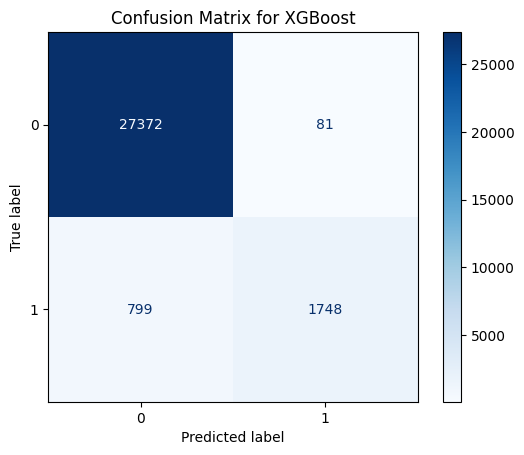

Confusion Matrix for XGBoost displayed.


In [ ]:

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=xgb_model.classes_)
disp_xgb.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for XGBoost')
plt.show()
print("Confusion Matrix for XGBoost displayed.")

In [ ]:
!pip install catboost

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cat_model = CatBoostClassifier(random_state=42, verbose=0)
cat_model.fit(X_train, y_train
y_pred_cat = cat_model.predict(X_test)

accuracy_cat = accuracy_score(y_test, y_pred_cat)
print(f"CatBoost Accuracy: {accuracy_cat:.4f}")
print(classification_report(y_test, y_pred_cat))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.7 MB/s eta 0:00:00
CatBoost Accuracy: 0.9712
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27453
           1       0.96      0.69      0.80      2547

    accuracy                           0.97     30000
   macro avg       0.97      0.84      0.89     30000
weighted avg       0.97      0.97      0.97     30000



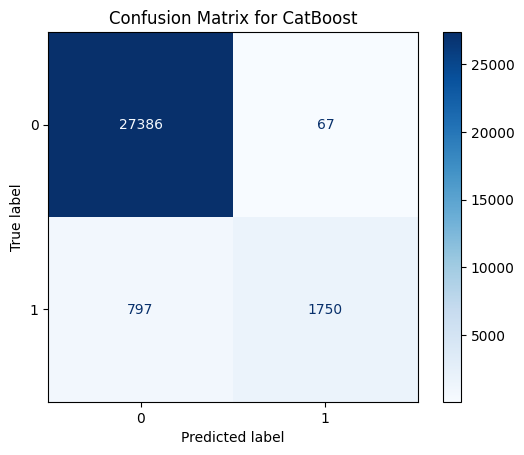

Confusion Matrix for CatBoost displayed.


In [ ]:

cm_cat = confusion_matrix(y_test, y_pred_cat)
disp_cat = ConfusionMatrixDisplay(confusion_matrix=cm_cat, display_labels=cat_model.classes_)
disp_cat.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for CatBoost')
plt.show()
print("Confusion Matrix for CatBoost displayed.")

In [ ]:
pip install lightgbm

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)

accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
print(f"LightGBM Accuracy: {accuracy_lgbm:.4f}")
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 5953, number of negative: 64047
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007037 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 409
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.085043 -> initscore=-2.375722
[LightGBM] [Info] Start training from score -2.375722
LightGBM Accuracy: 0.9716
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27453
           1       0.98      0.68      0.80      2547

    accuracy                           0.97     30000
   macro avg       0.97      0.84      0.89     30000
weighted avg       0.97      0.97      0.97     30000



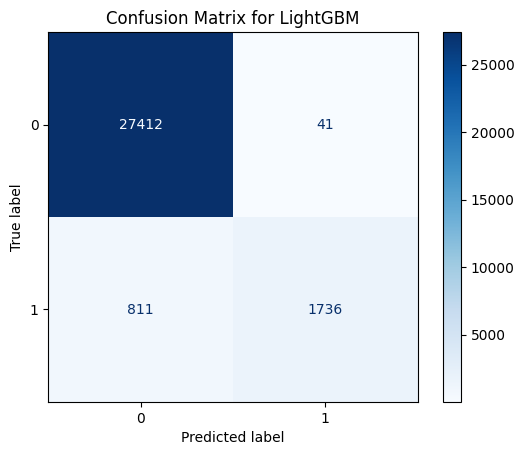

Confusion Matrix for LightGBM displayed.


In [ ]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
disp_lgbm = ConfusionMatrixDisplay(confusion_matrix=cm_lgbm, display_labels=lgbm_model.classes_)
disp_lgbm.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for LightGBM')
plt.show()
print("Confusion Matrix for LightGBM displayed.")

In [ ]:
model_accuracies = {
    'Random Forest': accuracy_score(y_test, y_pred),
    'SVM': accuracy_score(y_test, y_pred_svm),
    'Gradient Boosting': accuracy_score(y_test, y_pred_gb),
    'AdaBoost': accuracy_score(y_test, y_pred_ada),
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'XGBoost': accuracy_xgb,
    'CatBoost': accuracy_cat,
    'LightGBM': accuracy_lgbm
}

print("Model Accuracies:", model_accuracies)

Model Accuracies: {'Random Forest': 0.9705666666666667, 'SVM': 0.9473666666666667, 'Gradient Boosting': 0.9718666666666667, 'AdaBoost': 0.9715333333333334, 'Logistic Regression': 0.9589, 'XGBoost': 0.9706666666666667, 'CatBoost': 0.9712, 'LightGBM': 0.9716}


In [ ]:
from sklearn.metrics import classification_report

models = {
    'Random Forest': (model, X_test, y_test, y_pred),
    'SVM': (svm, X_test, y_test, y_pred_svm),
    'Gradient Boosting': (gb, X_test, y_test, y_pred_gb),
    'AdaBoost': (ada, X_test, y_test, y_pred_ada),
    'Logistic Regression': (log_reg, X_test_scaled, y_test, y_pred_lr),
    'XGBoost': (xgb_model, X_test, y_test, y_pred_xgb),
    'CatBoost': (cat_model, X_test, y_test, y_pred_cat),
    'LightGBM': (lgbm_model, X_test, y_test, y_pred_lgbm)
}

results = []

for name, (mdl, X_t, y_t, y_p) in models.items():
    report = classification_report(y_t, y_p, output_dict=True)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_t, y_p),
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-score': report['weighted avg']['f1-score']
    })

comparison_df = pd.DataFrame(results)
print("\nFull Model Comparison Table:")
print(comparison_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True))


Full Model Comparison Table:
                 Model  Accuracy  Precision    Recall  F1-score
0    Gradient Boosting  0.971867   0.972324  0.971867  0.969441
1             LightGBM  0.971600   0.971745  0.971600  0.969268
2             AdaBoost  0.971533   0.972372  0.971533  0.968892
3             CatBoost  0.971200   0.970991  0.971200  0.968980
4              XGBoost  0.970667   0.970286  0.970667  0.968450
5        Random Forest  0.970567   0.970208  0.970567  0.968316
6  Logistic Regression  0.958900   0.956396  0.958900  0.955686
7                  SVM  0.947367   0.950229  0.947367  0.936280
